# Crímenes reportados en Chicago — Grupo 2

Estructura del trabajo: **1. Introducción al problema** ⟶ **2. Datos (descripción y preparación)** ⟶ **3. Entrenamiento** ⟶ **4. Métricas y evaluación** ⟶ **5. Conclusiones**.

🖥 **al ejecutarlo en collab con las instancias gratuitas no puede terminar de entrenar porque se queda sin memoria. Se deberia poder correr localmente sin problemas**

Integrantes:
- Romero Federico.
- Ailen Muñoz.

## 1. Introducción al problema

**Contexto.** Trabajamos con el registro público de crímenes reportados en la ciudad de Chicago durante 2022: 240.091 incidentes con su tipo de delito, resolución (arresto o no), contexto (doméstico, tipo de lugar), ubicación y fecha.

Nota: El EDA presentado es la versión condensada del desarrollado en la materia Análisis de Datos, pero aplica **exactamente el mismo pipeline** de limpieza, split, imputación, feature engineering y codificación, por lo que el dataset final resultante (`df_train_encoded`, `df_test_encoded`, `y_train`, `y_test`) es **idéntico**.

**Tipo de problema.** Clasificación **multiclase**: predecir el tipo principal de crimen a partir de las características contextuales del incidente reportado.

**Variable target.** `Primary Type` (31 clases: THEFT, BATTERY, CRIMINAL DAMAGE, etc.). Se eligió por su granularidad adecuada: es más interpretable que los códigos `IUCR`/`FBI Code` y menos fragmentada que `Description`, que generaría un número excesivo de clases con pocos datos.

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

sns.set_style('whitegrid')

Matplotlib is building the font cache; this may take a moment.


## 2. Datos

### 2.1 Carga del dataset

El notebook lee `reported_crimes.csv` (c[rímenes reportados en Chicago durante 2022](https://data.cityofchicago.org/Public-Safety/Crimes-2022/9hwr-2zxp/about_data)). Si el archivo no está disponible localmente (p. ej. en Google Colab), se descarga desde Google Drive.

Tras la carga se aplica el **retipado** definido en el EDA completo: fechas a `datetime`, texto a `string`, códigos geográficos a `float`.

In [ ]:
file_name = 'reported_crimes.csv'
file_id = '1qBJaFim1vcqY2tBmnfMeYdhUp9Xshr6h'

if not os.path.exists(file_name):
    import gdown  # preinstalado en Google Colab
    gdown.download(id=file_id, output=file_name, quiet=False)
    print(f"'{file_name}' descargado exitosamente.")

df = pd.read_csv(file_name)

# --- Retipado (idéntico al notebook completo) ---
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y %I:%M:%S %p', errors='coerce')
df['Updated On'] = pd.to_datetime(df['Updated On'], format='%Y %b %d %I:%M:%S %p', errors='coerce')

string_columns = [
    'Case Number', 'Block', 'IUCR', 'Primary Type', 'Description',
    'Location Description', 'FBI Code'
]
for col in string_columns:
    if col in df.columns:
        df[col] = df[col].astype('string')

df['Location'] = df['Location'].replace('nan', np.nan).astype('object')

float_columns = ['Ward', 'Community Area', 'X Coordinate', 'Y Coordinate', 'Latitude', 'Longitude']
for col in float_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print(f"Shape del DataFrame: {df.shape}")
df.head()

Downloading...
From: https://drive.google.com/uc?id=1qBJaFim1vcqY2tBmnfMeYdhUp9Xshr6h
To: /Users/feche/maestria IA/ML/reported_crimes.csv
100%|██████████| 68.7M/68.7M [00:28<00:00, 2.41MB/s]


'reported_crimes.csv' descargado exitosamente.
Shape del DataFrame: (240091, 22)


,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
0,13024128,JG202134,2022-12-31 23:55:00,055XX W ADAMS ST,1477,WEAPONS VIOLATION,RECKLESS FIREARM DISCHARGE,RESIDENCE - YARD (FRONT / BACK),False,False,...,29.0,25.0,15,1139642.0,1898786.0,2022,2023-11-15 15:41:31,41.878374,-87.762732,POINT (-87.762731975 41.878373984)
1,12938337,JG100016,2022-12-31 23:50:00,014XX W LUNT AVE,0910,MOTOR VEHICLE THEFT,AUTOMOBILE,ALLEY,False,False,...,49.0,1.0,07,1165385.0,1946614.0,2022,2023-01-07 15:41:08,42.009108,-87.666844,POINT (-87.666843608 42.009107852)
2,12938426,JG100085,2022-12-31 23:50:00,055XX W WASHINGTON BLVD,0486,BATTERY,DOMESTIC BATTERY SIMPLE,APARTMENT,False,True,...,29.0,25.0,08B,1139357.0,1900199.0,2022,2023-01-07 15:41:08,41.882257,-87.763744,POINT (-87.763744015 41.882256634)
3,12938351,JG100087,2022-12-31 23:47:00,091XX S LAFLIN ST,0560,ASSAULT,SIMPLE,STREET,True,False,...,21.0,73.0,08A,1167940.0,1844124.0,2022,2023-01-07 15:41:08,41.727812,-87.660399,POINT (-87.660399127 41.72781203)
4,12938340,JG100005,2022-12-31 23:47:00,091XX S LAFLIN ST,143A,WEAPONS VIOLATION,UNLAWFUL POSSESSION - HANDGUN,APARTMENT,True,False,...,21.0,73.0,15,1167940.0,1844124.0,2022,2023-01-07 15:41:08,41.727812,-87.660399,POINT (-87.660399127 41.72781203)


### 2.2 Descripción de los datos: EDA resumido

**El dataset:** 240.091 crímenes reportados en Chicago durante 2022, con 22 variables: identificadores del caso (`ID`, `Case Number`), categorización del delito (`Primary Type`, `Description`, `IUCR`, `FBI Code`), resolución (`Arrest`), contexto (`Domestic`, `Location Description`), temporales (`Date`, `Year`, `Updated On`) y ubicación (coordenadas, `Location`, `Block` y las segmentaciones `Beat`, `District`, `Ward`, `Community Area`).

**Hallazgos y decisiones de curado** (el desarrollo y la justificación completa de cada punto está en el notebook original):

| # | Hallazgo del EDA | Decisión de curado |
|---|------------------|--------------------|
| 1 | **47 filas duplicadas** por `Case Number`: son actualizaciones del mismo caso en distintos momentos (`Updated On`) | Conservar la versión más reciente de cada caso (último `Updated On`) |
| 2 | **Faltantes geográficos (MAR)** en `Community Area`, `Ward`, coordenadas, etc. Muchos `Beat` mapean casi unívocamente a una `Community Area` | Imputar `Community Area` con la **moda por `Beat`** (ajustada solo en train, sin data leakage) |
| 3 | **Faltantes estructurales (MNAR)** en `Location Description`: corresponden a crímenes sin ubicación física (estafas telefónicas/virtuales, p. ej. *financial identity theft*) | Imputar con la nueva categoría **`'VIRTUAL'`** (la ausencia es informativa) |
| 4 | **Redundancia geográfica**: `Location`, `Latitude`/`Longitude`, `X`/`Y Coordinate`, `District`, `Ward` y `Block` no aportan frente a `Beat` (granular) + `Community Area` (interpretable) | Eliminarlas |
| 5 | **Data leakage**: `IUCR` y `FBI Code` tienen relación casi determinística con el target (un IUCR ↔ un `Primary Type`); `Description` también lo determina en la práctica | Excluirlas de las features del modelo |
| 6 | **Sin valor predictivo**: `ID`, `Case Number`, `Updated On` (identificadores/metadatos) y `Year` (constante = 2022, varianza nula) | Eliminarlas |
| 7 | **Desbalance natural del target**: THEFT ≈ 23 %, BATTERY ≈ 17 %, CRIMINAL DAMAGE ≈ 11 %. Se evaluó agrupar clases minoritarias en `OTHERS`, pero la entropía relativa solo mejoraba ~2 % | Conservar las **31 clases originales** (el desbalance refleja la realidad del fenómeno) |
| 8 | **Outliers y escalado**: tras el curado, todas las features son categóricas | No aplica tratamiento estadístico de outliers ni escalado |

> El desbalance de las variables **no-target** (`Arrest`, `Domestic`, etc.) tampoco se corrige: refleja la realidad del fenómeno (la mayoría de los crímenes no termina en arresto) y es información legítima para el modelo.

Case Numbers duplicados: 43 | Filas en exceso: 47


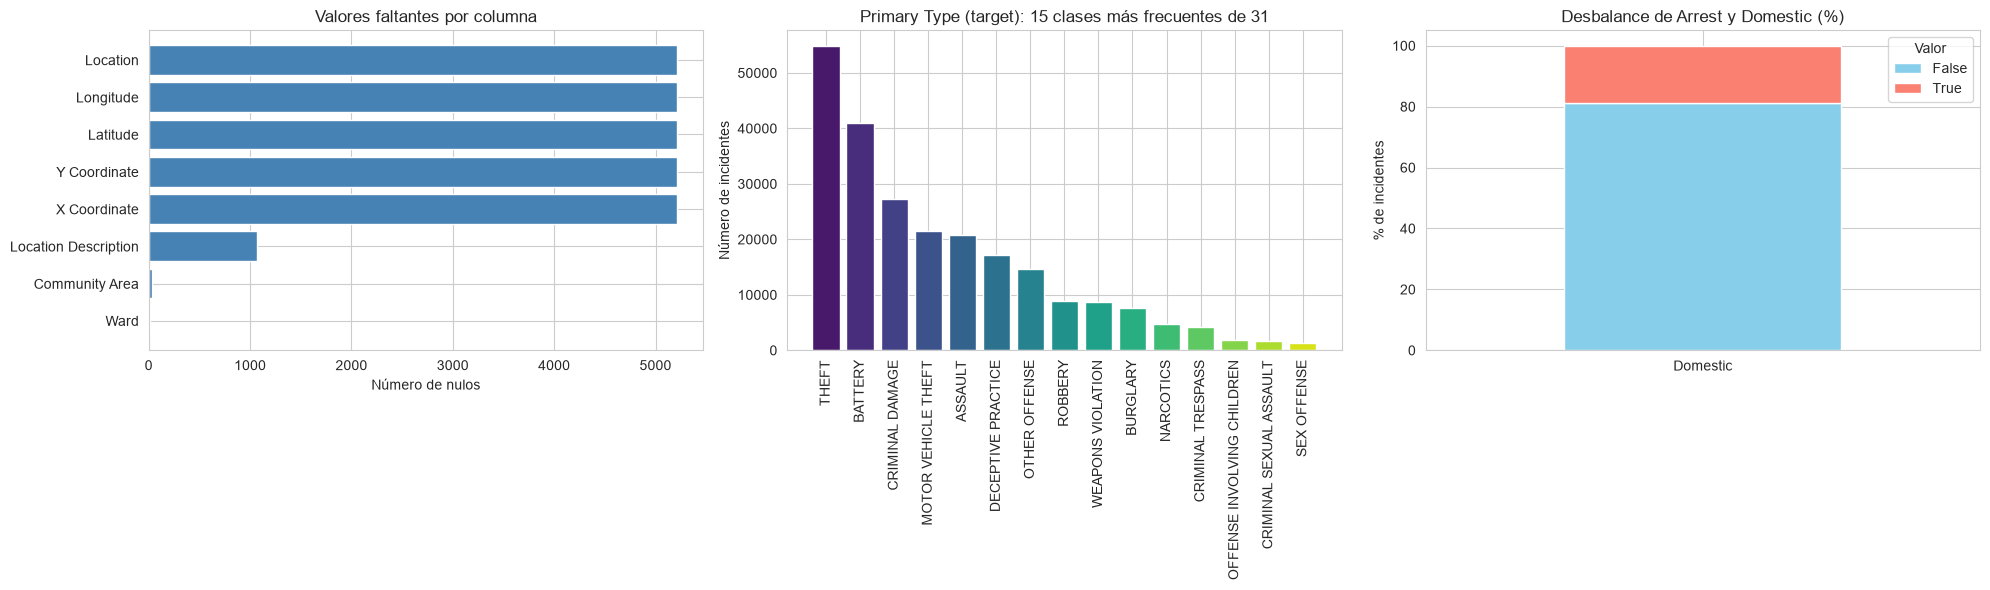

In [ ]:
# --- Vista rápida de los hallazgos principales ---

# Duplicados por Case Number
duplicates_by_case = df.groupby('Case Number').size()
print(f"Case Numbers duplicados: {(duplicates_by_case > 1).sum()}"
      f" | Filas en exceso: {(duplicates_by_case - 1).sum()}")

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Valores faltantes por columna
nulls = df.isnull().sum()
nulls = nulls[nulls > 0].sort_values()
axes[0].barh(nulls.index, nulls.values, color='steelblue')
axes[0].set_title('Valores faltantes por columna')
axes[0].set_xlabel('Número de nulos')

# 2. Desbalance del target (Top 15)
vc = df['Primary Type'].value_counts().head(15)
axes[1].bar(vc.index, vc.values, color=sns.color_palette('viridis', len(vc)))
axes[1].set_title('Primary Type (target): 15 clases más frecuentes de 31')
axes[1].set_ylabel('Número de incidentes')
axes[1].tick_params(axis='x', rotation=90)

# 3. Desbalance de Arrest y Domestic
balance = pd.DataFrame({
    'Arrest': df['Arrest'].value_counts(normalize=True) * 100,
    'Domestic': df['Domestic'].value_counts(normalize=True) * 100,
}).T[[False, True]]
balance.plot(kind='bar', stacked=True, ax=axes[2], color=['skyblue', 'salmon'], rot=0)
axes[2].set_title('Desbalance de Arrest y Domestic (%)')
axes[2].set_ylabel('% de incidentes')
axes[2].legend(title='Valor')

plt.tight_layout()
plt.show()

### 2.3 Preparación: curado del dataset

Aplicamos las decisiones del EDA **en el mismo orden que el notebook completo**, para obtener exactamente el mismo dataset final.

#### Duplicados y columnas descartadas

In [ ]:
# 1. Eliminación de duplicados por Case Number: conservamos el último 'Updated On'
print(f"Filas antes de eliminar duplicados: {len(df)}")

df_cleaned = df.loc[df.groupby('Case Number')['Updated On'].idxmax()]
df = df_cleaned.copy()

print(f"Filas después: {len(df)}")

Filas antes de eliminar duplicados: 240091
Filas después: 240044


In [ ]:
# 2. Eliminación de columnas: geográficas redundantes + identificadores/constantes
df_post_null_process = df.copy()

geo_columns_to_drop = [
    'Location', 'Latitude', 'Longitude', 'X Coordinate', 'Y Coordinate',
    'District', 'Ward', 'Block'
]
df_post_null_process = df_post_null_process.drop(columns=geo_columns_to_drop, errors='ignore')

columns_to_drop_modeling = ['ID', 'Case Number', 'Updated On', 'Year']
df_post_null_process = df_post_null_process.drop(columns=columns_to_drop_modeling, errors='ignore')

print(f"Columnas eliminadas: {geo_columns_to_drop + columns_to_drop_modeling}")
print(f"Columnas restantes ({df_post_null_process.shape[1]}): {df_post_null_process.columns.tolist()}")

Columnas eliminadas: ['Location', 'Latitude', 'Longitude', 'X Coordinate', 'Y Coordinate', 'District', 'Ward', 'Block', 'ID', 'Case Number', 'Updated On', 'Year']
Columnas restantes (10): ['Date', 'IUCR', 'Primary Type', 'Description', 'Location Description', 'Arrest', 'Domestic', 'Beat', 'Community Area', 'FBI Code']


#### Split estratificado (antes de imputar)

Partición 80/20 **estratificada por `Primary Type`**: como las clases están desbalanceadas, la estratificación garantiza que la proporción de cada tipo de crimen se mantenga en train y test. `random_state=42` para reproducibilidad.

El split se hace **antes de imputar** para que los parámetros de imputación se ajusten solo con train y no haya fuga de información (*data leakage*).

In [ ]:
target = 'Primary Type'

df_train, df_test = train_test_split(
    df_post_null_process,
    test_size=0.2,
    random_state=42,
    stratify=df_post_null_process[target]
)

print(f"Tamaño train: {df_train.shape[0]} filas ({df_train.shape[0] / len(df_post_null_process):.0%})")
print(f"Tamaño test:  {df_test.shape[0]} filas ({df_test.shape[0] / len(df_post_null_process):.0%})")

Tamaño train: 192035 filas (80%)
Tamaño test:  48009 filas (20%)


#### Imputación de faltantes (ajustada solo en train)

- **`Community Area` (MAR):** moda de `Community Area` por `Beat`, calculada sobre train; para Beats no vistos en train, moda global de train como respaldo.
- **`Location Description` (MNAR estructural):** valor constante `'VIRTUAL'`.

In [ ]:
# --- Community Area: moda por Beat, AJUSTADA SOLO CON TRAIN ---
beat_mode = (
    df_train.groupby('Beat')['Community Area']
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
)
global_mode = df_train['Community Area'].mode().iloc[0]  # respaldo para Beats no vistos en train

def impute_community_area(frame):
    frame = frame.copy()
    fill = frame['Beat'].map(beat_mode).fillna(global_mode)
    frame['Community Area'] = frame['Community Area'].fillna(fill)
    return frame

df_train = impute_community_area(df_train)
df_test = impute_community_area(df_test)

# --- Location Description: faltante estructural -> valor constante 'VIRTUAL' ---
df_train['Location Description'] = df_train['Location Description'].fillna('VIRTUAL')
df_test['Location Description'] = df_test['Location Description'].fillna('VIRTUAL')

print("Nulos tras la imputación:")
print(pd.DataFrame({
    'train': df_train[['Community Area', 'Location Description']].isnull().sum(),
    'test':  df_test[['Community Area', 'Location Description']].isnull().sum(),
}))

Nulos tras la imputación:
                      train  test
Community Area            0     0
Location Description      0     0


#### Feature engineering temporal

De `Date` derivamos **`Day of week`**, **`Month`** y **`Moment of day`** (tres franjas equitativas de 8 h: MORNING 6–14 h, AFTERNOON 14–22 h, NIGHT 22–6 h) y luego eliminamos `Date`. Son transformaciones deterministas por fila, por lo que aplicarlas después del split no introduce data leakage.

En el EDA completo se observaron patrones temporales claros por tipo de crimen (horarios, días y meses con frecuencias diferenciadas), lo que justifica estas features.

In [ ]:
def get_moment_of_day(hour):
    # Tres franjas equitativas de 8 horas cada una.
    if 6 <= hour < 14:
        return 'MORNING'      # 06-14h
    elif 14 <= hour < 22:
        return 'AFTERNOON'    # 14-22h
    else:
        return 'NIGHT'        # 22-06h

def add_temporal_features(frame):
    frame = frame.copy()
    frame['Day of week'] = frame['Date'].dt.day_name()
    frame['Month'] = frame['Date'].dt.month_name()
    frame['Moment of day'] = frame['Date'].dt.hour.apply(get_moment_of_day)
    return frame.drop(columns=['Date'])

df_train = add_temporal_features(df_train)
df_test = add_temporal_features(df_test)

print("Columnas 'Day of week', 'Month' y 'Moment of day' creadas; 'Date' eliminada (train y test).")
df_train.head()

Columnas 'Day of week', 'Month' y 'Moment of day' creadas; 'Date' eliminada (train y test).


,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,Beat,Community Area,FBI Code,Day of week,Month,Moment of day
36674,0810,THEFT,OVER $500,RESIDENCE,False,False,1813,7.0,06,Sunday,November,MORNING
173558,1154,DECEPTIVE PRACTICE,FINANCIAL IDENTITY THEFT $300 AND UNDER,APARTMENT,False,False,1934,6.0,11,Friday,April,MORNING
100453,0820,THEFT,$500 AND UNDER,RESIDENCE - PORCH / HALLWAY,False,False,631,44.0,06,Friday,August,AFTERNOON
35954,5002,OTHER OFFENSE,OTHER VEHICLE OFFENSE,STREET,False,False,2523,21.0,26,Monday,November,MORNING
164864,1320,CRIMINAL DAMAGE,TO VEHICLE,STREET,False,False,1135,27.0,14,Friday,May,NIGHT


### 2.4 Selección de features (filtros)

En el notebook completo se evaluaron **relevancia** (V de Cramér y mutual information de cada feature contra el target) y **redundancia** (V de Cramér entre features), siempre sobre train. Conclusiones:

- `Arrest`, `Domestic` y `Location Description` son las features más informativas sobre el tipo de crimen; las temporales aportan señal débil pero su costo dimensional es bajo, así que se conservan.
- **`Beat` ↔ `Community Area`: V de Cramér ≈ 0,86** — son casi la misma información geográfica. Se conserva `Beat` (más granular: 283 vs 77 categorías) y se **excluye `Community Area`**.
- **PCA** se implementó y evaluó sobre la matriz codificada: el espectro de varianza resultó muy plano (hacen falta 21 de 25 componentes para retener el 90 %), porque las features categóricas restantes son mayormente independientes entre sí. **No se adopta** — la reducción de dimensionalidad efectiva vino de la selección por filtros.

La celda siguiente reproduce en forma compacta la evidencia de los filtros sobre train:

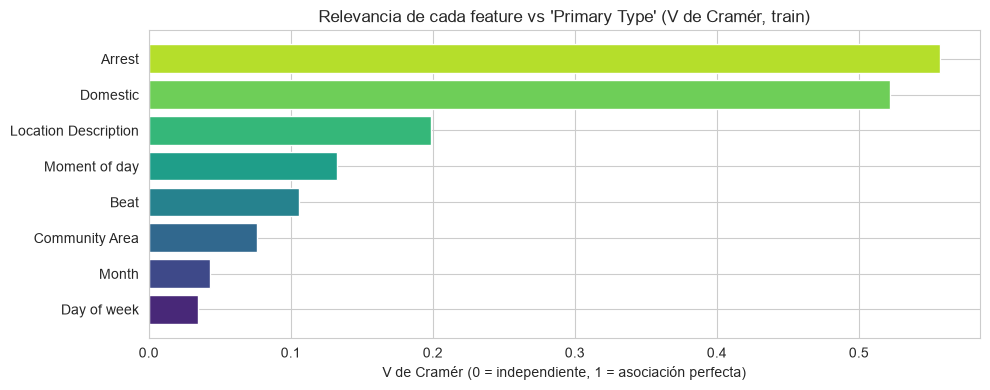

Redundancia Beat <-> Community Area (V de Cramér): 0.856


In [ ]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    # V de Cramér con corrección de sesgo (Bergsma) para dos series categóricas
    ct = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct, correction=False)[0]
    n = ct.values.sum()
    r, k = ct.shape
    phi2 = chi2 / n
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    denom = min(kcorr - 1, rcorr - 1)
    return np.sqrt(phi2corr / denom) if denom > 0 else 0.0

feature_cols = ['Location Description', 'Beat', 'Community Area', 'Arrest', 'Domestic',
                'Day of week', 'Month', 'Moment of day']
X_cat = df_train[feature_cols].astype(str)
y_cat = df_train[target].astype(str)

# Relevancia de cada feature candidata contra el target
cramers_target = pd.Series({c: cramers_v(X_cat[c], y_cat) for c in feature_cols}).sort_values(ascending=False)

plt.figure(figsize=(10, 4))
plt.barh(cramers_target.index[::-1], cramers_target.values[::-1],
         color=sns.color_palette('viridis', len(cramers_target)))
plt.title("Relevancia de cada feature vs 'Primary Type' (V de Cramér, train)")
plt.xlabel('V de Cramér (0 = independiente, 1 = asociación perfecta)')
plt.tight_layout()
plt.show()

# Redundancia Beat <-> Community Area (la única fuerte entre features)
print(f"Redundancia Beat <-> Community Area (V de Cramér): "
      f"{cramers_v(X_cat['Beat'], X_cat['Community Area']):.3f}")

In [ ]:
# Selección aplicada: Community Area queda EXCLUIDA de las features (redundante con Beat).
selected_features = ['Location Description', 'Beat', 'Arrest', 'Domestic',
                     'Day of week', 'Month', 'Moment of day']

print(f"Features seleccionadas ({len(selected_features)}): {selected_features}")

Features seleccionadas (7): ['Location Description', 'Beat', 'Arrest', 'Domestic', 'Day of week', 'Month', 'Moment of day']


### 2.5 Codificación de las features (ajustada solo en train)

Convertimos las categóricas a numéricas con tres técnicas según su naturaleza. **Todos los encoders se ajustan solo con train** y el target **no se codifica** (queda aparte como `y_train` / `y_test`):

- **Binary Encoding** para alta cardinalidad: `Location Description` (136 categorías → 8 columnas) y `Beat` (283 → 9). Evita la explosión de ~420 columnas del One-Hot y maneja categorías nuevas en test.
- **Codificación cíclica (seno/coseno)** para `Month`, `Day of week` y `Moment of day`: son variables cíclicas (diciembre↔enero, domingo↔lunes, NIGHT↔MORNING); un encoding ordinal impondría distancias falsas.
- **Ordinal Encoding** para los booleanos `Arrest` y `Domestic`.

In [ ]:
import sys
!{sys.executable} -m pip install category_encoders
from category_encoders import BinaryEncoder

# Binary Encoding para las features de alta cardinalidad (SIN el target)
binary_encoding_features = ['Location Description', 'Beat']

binary_encoder = BinaryEncoder(cols=binary_encoding_features, return_df=True)
binary_encoder.fit(df_train[binary_encoding_features])  # fit solo en train

df_train_binary_encoded = binary_encoder.transform(df_train[binary_encoding_features])
df_test_binary_encoded = binary_encoder.transform(df_test[binary_encoding_features])

print("Binary Encoding:")
print(f"  Train: {df_train_binary_encoded.shape}  |  Test: {df_test_binary_encoded.shape}")

/Users/feche/.cache/uv/archive-v0/fvVlLfKLxYjZiuKqm3O1O/bin/python: No module named pip
Binary Encoding:
  Train: (192035, 17)  |  Test: (48009, 17)


In [ ]:
from sklearn.preprocessing import OrdinalEncoder

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
moment_order = ['MORNING', 'AFTERNOON', 'NIGHT']

# --- Codificación cíclica: proyectamos cada feature temporal sobre un círculo ---
day_to_num = {d: i for i, d in enumerate(day_order)}
month_to_num = {m: i for i, m in enumerate(month_order)}
moment_to_num = {m: i for i, m in enumerate(moment_order)}

def add_cyclic_features(frame):
    out = pd.DataFrame(index=frame.index)
    dow = frame['Day of week'].map(day_to_num)
    month = frame['Month'].map(month_to_num)
    moment = frame['Moment of day'].map(moment_to_num)
    out['Day of week_sin'] = np.sin(2 * np.pi * dow / 7)
    out['Day of week_cos'] = np.cos(2 * np.pi * dow / 7)
    out['Month_sin'] = np.sin(2 * np.pi * month / 12)
    out['Month_cos'] = np.cos(2 * np.pi * month / 12)
    out['Moment of day_sin'] = np.sin(2 * np.pi * moment / 3)
    out['Moment of day_cos'] = np.cos(2 * np.pi * moment / 3)
    return out

df_train_cyclic = add_cyclic_features(df_train)
df_test_cyclic = add_cyclic_features(df_test)

# --- Ordinal Encoding: solo las variables booleanas ---
ordinal_features = ['Arrest', 'Domestic']
ordinal_encoder = OrdinalEncoder(
    categories=[[False, True], [False, True]],
    handle_unknown='use_encoded_value', unknown_value=-1)
ordinal_encoder.fit(df_train[ordinal_features])  # fit solo en train

df_train_ordinal = pd.DataFrame(
    ordinal_encoder.transform(df_train[ordinal_features]),
    columns=[f'ord_{c}' for c in ordinal_features], index=df_train.index)
df_test_ordinal = pd.DataFrame(
    ordinal_encoder.transform(df_test[ordinal_features]),
    columns=[f'ord_{c}' for c in ordinal_features], index=df_test.index)

print("Codificación cíclica (Month, Day of week, Moment of day):")
print(f"  Train: {df_train_cyclic.shape}  |  Test: {df_test_cyclic.shape}")
print("Ordinal Encoding (Arrest, Domestic):")
print(f"  Train: {df_train_ordinal.shape}  |  Test: {df_test_ordinal.shape}")

Codificación cíclica (Month, Day of week, Moment of day):
  Train: (192035, 6)  |  Test: (48009, 6)
Ordinal Encoding (Arrest, Domestic):
  Train: (192035, 2)  |  Test: (48009, 2)


In [ ]:
# Combinar features codificadas (cada conjunto con SU PROPIO encoding -> sin fuga)
df_train_encoded = pd.concat([
    df_train_binary_encoded.reset_index(drop=True),
    df_train_cyclic.reset_index(drop=True),
    df_train_ordinal.reset_index(drop=True),
], axis=1)
df_test_encoded = pd.concat([
    df_test_binary_encoded.reset_index(drop=True),
    df_test_cyclic.reset_index(drop=True),
    df_test_ordinal.reset_index(drop=True),
], axis=1)

# El target se mantiene aparte (no se codifica dentro de las features)
y_train = df_train[target].reset_index(drop=True)
y_test = df_test[target].reset_index(drop=True)

print("Dataset final codificado (solo features):")
print(f"  X_train: {df_train_encoded.shape}  |  X_test: {df_test_encoded.shape}")
print(f"  Columnas ({len(df_train_encoded.columns)}): {df_train_encoded.columns.tolist()}")
df_train_encoded.head()

Dataset final codificado (solo features):
  X_train: (192035, 25)  |  X_test: (48009, 25)
  Columnas (25): ['Location Description_0', 'Location Description_1', 'Location Description_2', 'Location Description_3', 'Location Description_4', 'Location Description_5', 'Location Description_6', 'Location Description_7', 'Beat_0', 'Beat_1', 'Beat_2', 'Beat_3', 'Beat_4', 'Beat_5', 'Beat_6', 'Beat_7', 'Beat_8', 'Day of week_sin', 'Day of week_cos', 'Month_sin', 'Month_cos', 'Moment of day_sin', 'Moment of day_cos', 'ord_Arrest', 'ord_Domestic']


,Location Description_0,Location Description_1,Location Description_2,Location Description_3,Location Description_4,Location Description_5,Location Description_6,Location Description_7,Beat_0,Beat_1,...,Beat_7,Beat_8,Day of week_sin,Day of week_cos,Month_sin,Month_cos,Moment of day_sin,Moment of day_cos,ord_Arrest,ord_Domestic
0,0,0,0,0,0,0,0,1,0,0,...,0,1,-0.781831,0.623490,-0.866025,5.000000e-01,0.000000,1.0,0.0,0.0
1,0,0,0,0,0,0,1,0,0,0,...,1,0,-0.433884,-0.900969,1.000000,6.123234e-17,0.000000,1.0,0.0,0.0
2,0,0,0,0,0,0,1,1,0,0,...,1,1,-0.433884,-0.900969,-0.500000,-8.660254e-01,0.866025,-0.5,0.0,0.0
3,0,0,0,0,0,1,0,0,0,0,...,0,0,0.000000,1.000000,-0.866025,5.000000e-01,0.000000,1.0,0.0,0.0
4,0,0,0,0,0,1,0,0,0,0,...,0,1,-0.433884,-0.900969,0.866025,-5.000000e-01,-0.866025,-0.5,0.0,0.0


### 2.6 Dataset final curado

- **X:** 25 features numéricas por observación — 17 de Binary Encoding (`Location Description` → 8, `Beat` → 9) + 6 cíclicas (`Month`, `Day of week`, `Moment of day` × 2) + 2 ordinales (`Arrest`, `Domestic`) — en `df_train_encoded` (~192k filas) y `df_test_encoded` (~48k filas).
- **y:** `Primary Type` sin codificar, en `y_train` / `y_test` (31 clases, desbalance natural conservado).
- **Sin nulos, sin duplicados y sin data leakage:** la imputación y todos los encoders se ajustaron únicamente con train.

Este output es **idéntico** al del notebook completo. La celda siguiente exporta el dataset curado a CSV para reutilizarlo directamente al entrenar el modelo.

In [ ]:
# Exportar el dataset curado (features codificadas + target) para el entrenamiento del modelo
train_out = pd.concat([df_train_encoded, y_train], axis=1)
test_out = pd.concat([df_test_encoded, y_test], axis=1)

train_out.to_csv('chicago_curado_train.csv', index=False)
test_out.to_csv('chicago_curado_test.csv', index=False)

print(f"Guardado 'chicago_curado_train.csv' ({train_out.shape[0]} filas x {train_out.shape[1]} columnas)")
print(f"Guardado 'chicago_curado_test.csv'  ({test_out.shape[0]} filas x {test_out.shape[1]} columnas)")

Guardado 'chicago_curado_train.csv' (192035 filas x 26 columnas)
Guardado 'chicago_curado_test.csv'  (48009 filas x 26 columnas)


## 3. Entrenamiento

### 3.1 Baseline

Como referencia mínima usamos un `DummyClassifier` con estrategia de **clase más frecuente**: ignora las features y predice siempre THEFT (≈ 23 % del train). Fija el piso que cualquier modelo debe superar para justificar su complejidad: accuracy ≈ 0,23 garantizada sin aprender nada, pero F1 macro ≈ 0 porque solo acierta 1 de las 31 clases — por eso reportamos ambas métricas. Se ajusta con el mismo train y se evalúa con el mismo test que el resto de los modelos.

In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score

# Baseline 1: siempre predice la clase mayoritaria (THEFT)
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(df_train_encoded, y_train)
y_pred_dummy = dummy.predict(df_test_encoded)

acc_dummy = accuracy_score(y_test, y_pred_dummy)
f1_dummy = f1_score(y_test, y_pred_dummy, average='macro')
print(f"Baseline mayoritario — accuracy: {acc_dummy:.3f} | F1 macro: {f1_dummy:.3f}")

Baseline mayoritario — accuracy: 0.229 | F1 macro: 0.012


### 3.2 Modelos: árbol de decisión y ensambles

- **Árbol de decisión** — Lo elegimos porque entrena rápido con ~192k observaciones y maneja bien las features categóricas codificadas. `class_weight='balanced'` por el desbalance de las 31 clases. Hiperparámetros (`max_depth`, `min_samples_leaf`, `criterion`) por búsqueda de grilla + validación cruzada estratificada de 3 folds, optimizando F1 macro.
- **Bagging** — 100 árboles sobre muestras bootstrap. El árbol quedó de máxima profundidad (alta varianza): justo el escenario donde bagging más aporta.
- **Random Forest** — 200 árboles, `max_features='sqrt'` para decorrelacionarlos, `class_weight='balanced'`.
- **Soft Voting** — Promedia las probabilidades del árbol tuneado, el bagging y el bosque. La diversidad del comité es limitada (los tres son modelos de árboles), pero permite contrastar la votación contra sus propios miembros.

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

param_grid_tree = {
    'max_depth': [10, 20, None],
    'min_samples_leaf': [1, 20, 100],
    'criterion': ['gini', 'entropy'],
}

grid_tree = GridSearchCV(
    DecisionTreeClassifier(class_weight='balanced', random_state=42),
    param_grid_tree, cv=cv, scoring='f1_macro', n_jobs=-1)
grid_tree.fit(df_train_encoded, y_train)

print(f"Mejores hiperparámetros: {grid_tree.best_params_}")
print(f"Mejor F1 macro (validación cruzada): {grid_tree.best_score_:.3f}")

tree = grid_tree.best_estimator_
y_pred_tree = tree.predict(df_test_encoded)

Mejores hiperparámetros: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1}
Mejor F1 macro (validación cruzada): 0.137


In [ ]:
from sklearn.ensemble import BaggingClassifier
from sklearn.base import clone

bagging = BaggingClassifier(
    estimator=clone(tree),
    n_estimators=100, n_jobs=-1, random_state=42)
bagging.fit(df_train_encoded, y_train)
y_pred_bagging = bagging.predict(df_test_encoded)

print("Bagging (100 árboles sobre muestras bootstrap) entrenado.")

/Users/feche/.cache/uv/archive-v0/fvVlLfKLxYjZiuKqm3O1O/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Bagging (100 árboles sobre muestras bootstrap) entrenado.


In [ ]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(
    n_estimators=200, class_weight='balanced', n_jobs=-1, random_state=42)
random_forest.fit(df_train_encoded, y_train)
y_pred_rf = random_forest.predict(df_test_encoded)

print("Random Forest (200 árboles, max_features='sqrt') entrenado.")

Random Forest (200 árboles, max_features='sqrt') entrenado.


In [ ]:
from sklearn.ensemble import VotingClassifier

# Soft Voting: promedia las probabilidades de los tres modelos de árboles
voting = VotingClassifier(
    estimators=[
        ('tree', clone(tree)),
        ('bagging', clone(bagging)),
        ('rf', clone(random_forest)),
    ],
    voting='soft', n_jobs=-1)
voting.fit(df_train_encoded, y_train)
y_pred_voting = voting.predict(df_test_encoded)

print("Soft Voting (árbol + bagging + bosque) entrenado.")

Soft Voting (árbol + bagging + bosque) entrenado.


## 4. Métricas y evaluación

Al ser un problema multiclase con **desbalance natural del target**, la accuracy sola no alcanza (el baseline mayoritario ya "acierta" el 23 % sin aprender nada). Reportamos tres métricas complementarias sobre **test**:

In [ ]:
from sklearn.metrics import balanced_accuracy_score

predicciones = {
    'Baseline mayoritario': y_pred_dummy,
    'Árbol de decisión (tuneado)': y_pred_tree,
    'Bagging (árbol)': y_pred_bagging,
    'Random Forest': y_pred_rf,
    'Soft Voting': y_pred_voting,
}

resultados = pd.DataFrame({
    nombre: {
        'Accuracy': accuracy_score(y_test, pred),
        'Exactitud balanceada': balanced_accuracy_score(y_test, pred),
        'F1 macro': f1_score(y_test, pred, average='macro'),
    }
    for nombre, pred in predicciones.items()
}).T.round(3).sort_values('F1 macro', ascending=False)

resultados

,Accuracy,Exactitud balanceada,F1 macro
Random Forest,0.300,0.207,0.171
Bagging (árbol),0.322,0.174,0.167
Soft Voting,0.253,0.152,0.142
Árbol de decisión (tuneado),0.245,0.145,0.136
Baseline mayoritario,0.229,0.032,0.012


La matriz de confusión del Random forest, que fue el mejor modelo (normalizada por fila, sobre las 10 clases reales más frecuentes por legibilidad) muestra en qué clases acierta y con cuáles se confunde.

Mejor modelo según F1 macro: Random Forest


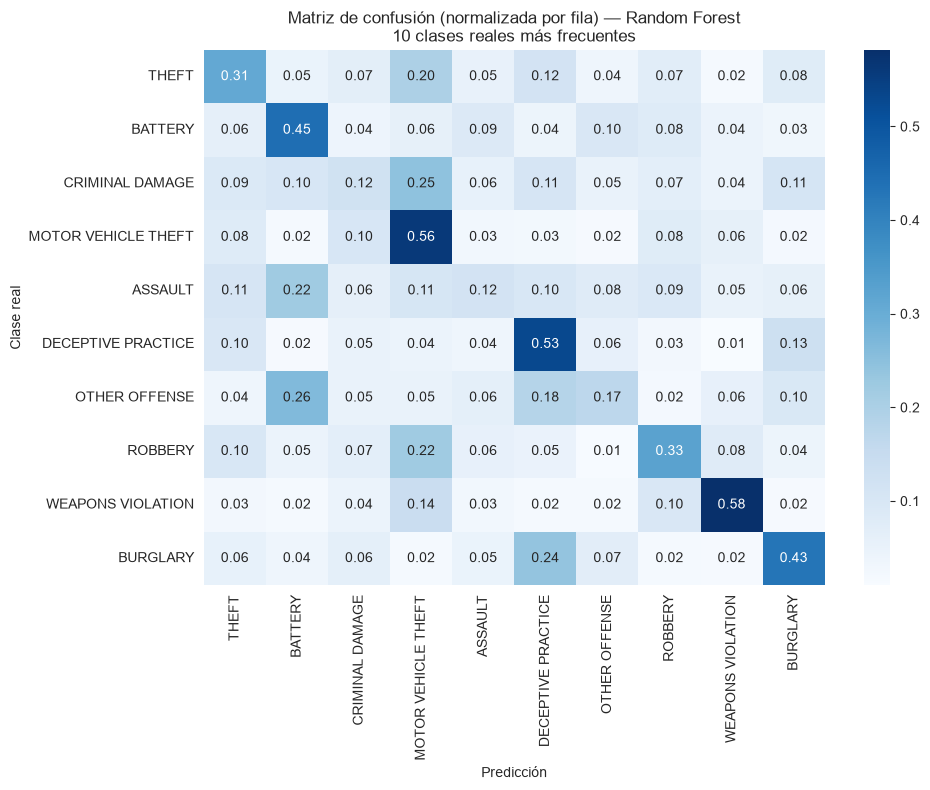

In [ ]:
from sklearn.metrics import confusion_matrix

mejor_nombre = resultados.index[0]
mejor_pred = predicciones[mejor_nombre]
print(f"Mejor modelo según F1 macro: {mejor_nombre}")

top10 = y_test.value_counts().head(10).index.tolist()
mask = y_test.isin(top10).to_numpy()
cm = confusion_matrix(y_test[mask], mejor_pred[mask], labels=top10, normalize='true')

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=top10, yticklabels=top10)
plt.title(f'Matriz de confusión (normalizada por fila) — {mejor_nombre}\n10 clases reales más frecuentes')
plt.xlabel('Predicción')
plt.ylabel('Clase real')
plt.tight_layout()
plt.show()

Como interpretabilidad adicional del bosque: la **importancia de features** (reducción media de impureza) muestra qué variables usan más los árboles para separar los tipos de crimen.

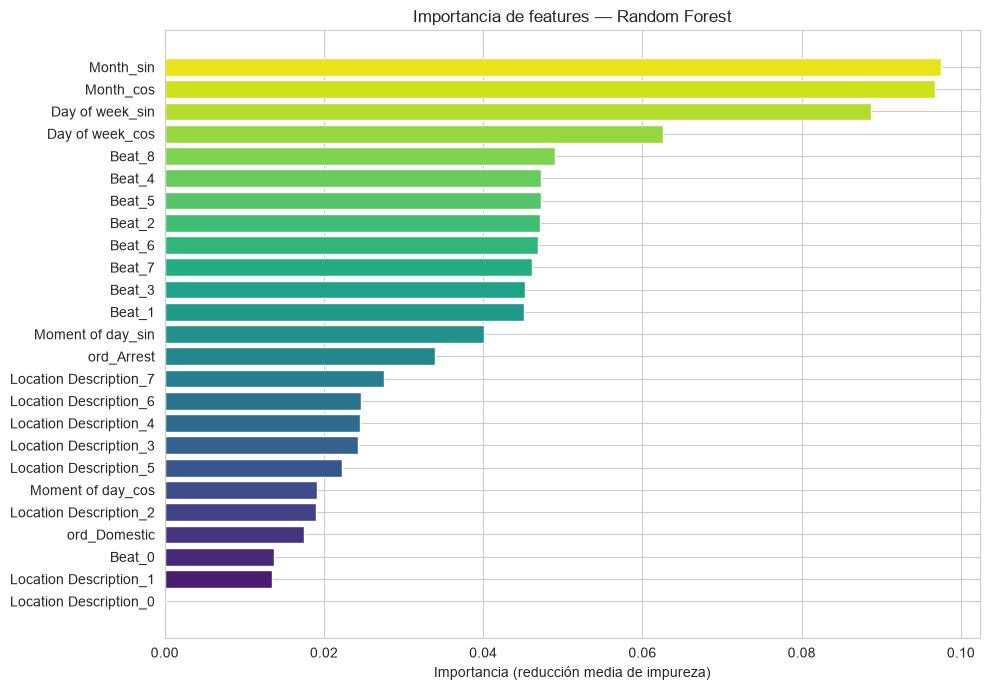

In [ ]:
importancias = pd.Series(
    random_forest.feature_importances_, index=df_train_encoded.columns).sort_values()

plt.figure(figsize=(10, 7))
plt.barh(importancias.index, importancias.values,
         color=sns.color_palette('viridis', len(importancias)))
plt.title('Importancia de features — Random Forest')
plt.xlabel('Importancia (reducción media de impureza)')
plt.tight_layout()
plt.show()

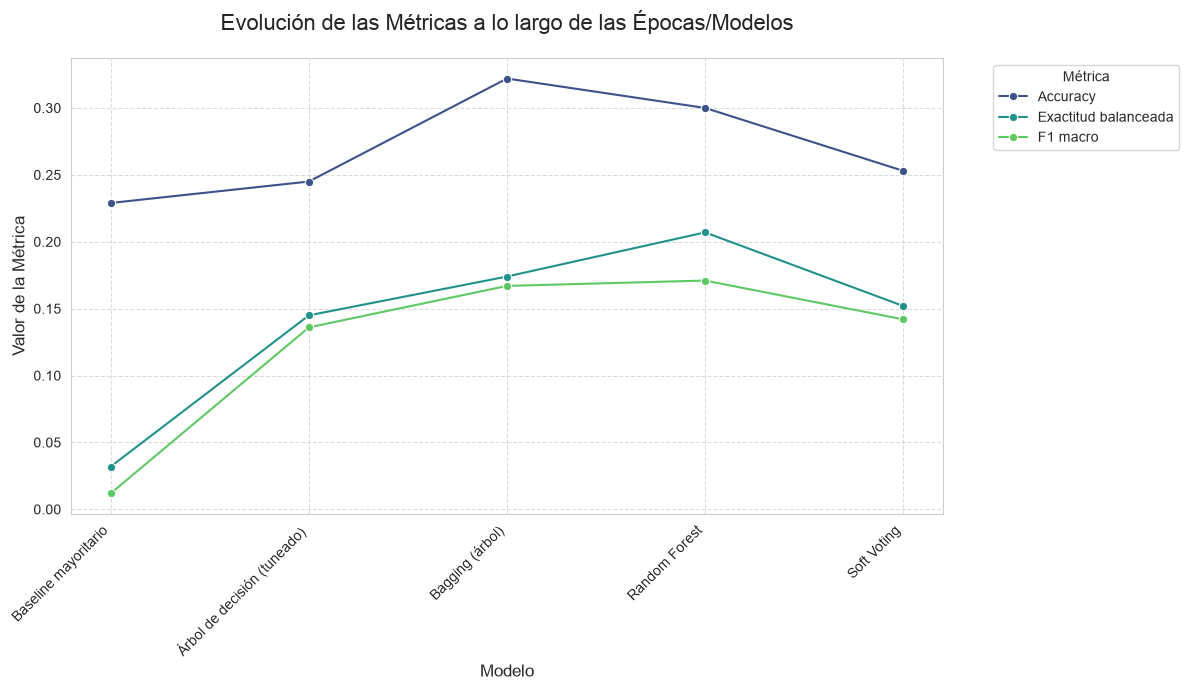

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Preparar los datos para la visualización de la línea de tiempo
metrics_df = resultados.reset_index().rename(columns={'index': 'Modelo'})
metrics_df_melted = metrics_df.melt(id_vars='Modelo', var_name='Métrica', value_name='Valor')

# Definir el orden de los modelos para la línea de tiempo
model_order = [
    'Baseline mayoritario',
    'Árbol de decisión (tuneado)',
    'Bagging (árbol)',
    'Random Forest',
    'Soft Voting'
]
metrics_df_melted['Modelo'] = pd.Categorical(metrics_df_melted['Modelo'], categories=model_order, ordered=True)

plt.figure(figsize=(12, 7))
sns.lineplot(
    data=metrics_df_melted,
    x='Modelo',
    y='Valor',
    hue='Métrica',
    marker='o',
    palette='viridis'
)
plt.title('Evolución de las Métricas a lo largo de las Épocas/Modelos',
          fontsize=16, pad=20)
plt.xlabel('Modelo',
           fontsize=12)
plt.ylabel('Valor de la Métrica',
           fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Métrica', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Elección del modelo final

Elegimos **Random Forest**:

- **Mejor F1 macro (0,171)**: +26 % sobre el árbol individual (0,136) y 14 veces el del baseline (0,012).
- **Mejor exactitud balanceada (0,207)**, con margen claro sobre el segundo (bagging, 0,174; +19 %). Dado que el dataset está desbalanceado —el baseline mayoritario ya logra 0,229 de accuracy solo por predecir la clase más frecuente—, esta métrica y F1 macro son más informativas que la accuracy simple.
- **Cede en accuracy frente a bagging (0,300 vs. 0,322)**, pero esa métrica es la menos confiable acá: se puede inflar prediciendo mayoritariamente la clase dominante, que es justamente lo que penalizan la exactitud balanceada y el F1 macro.
- **El Soft Voting (F1 0,142) no logra imponerse:** mejora al árbol solo, pero no alcanza a bagging ni al bosque: al promediar con el árbol individual,  la votación arrastra la varianza de ese miembro.


## 5. Conclusiones

-Completamos el recorrido **baseline → árbol de decisión → ensambles**. El modelo final elegido es **Random Forest** (accuracy **0,300** | exactitud balanceada **0,207** | F1 macro **0,171**): gana en las dos métricas más relevantes para este problema desbalanceado —exactitud balanceada y F1 macro—, cede algo de accuracy frente al bagging (**0,322**), y multiplica **por 14** el F1 macro del baseline.

- Los ensambles rindieron según lo esperado: el bagging redujo la varianza del árbol profundo (F1 **0,136 → 0,167**) y la decorrelación del Random Forest sumó el resto (**→ 0,171**), además de aportar el salto más grande en exactitud balanceada (**0,145 → 0,207**). El soft voting (**0,142**) mejoró al árbol pero no a los ensambles de bootstrap.

- Los valores absolutos son modestos y consistentes con el EDA: las features disponibles (**lugar, arresto, contexto doméstico, momento**) tienen asociación débil con el tipo de crimen. El techo de predictibilidad lo pone **la información del dataset**, no el pipeline.

- También probamos **KNN** —sobre una submuestra de **25.000 observaciones**, por su costo de predicción con **192k filas** de train— y un **SVM lineal**: sus métricas (F1 macro **0,099** y **0,078**; accuracy **0,267** y **0,204**) quedaron muy por debajo de las de los modelos de árboles, por lo que los descartamos del análisis final.